# Практична робота №17
## Проста лінійна регресія: побудова моделі, коефіцієнти, залишки, коефіцієнт детермінації
**Виконав:** Хрустовський Павло  
**Група:** ІТ-42  
**Варіант:** 6 (Чернігів)  
**№ у журналі:** 26


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

np.random.seed(6)
months = np.arange(1, 13)
temp_obs = 8.0 + 13.0 * np.cos((months - 7) / 12 * 2 * np.pi) + np.random.normal(0, 1.0, 12)
heating_cost = 200 - 8.5 * temp_obs + np.random.normal(0, 12.0, 12)

reg_res = linregress(temp_obs, heating_cost)

print(f"Оцінений нахил (slope b1): {reg_res.slope:.3f}")
print(f"Вільний член (intercept b0): {reg_res.intercept:.3f}")
print(f"Коефіцієнт детермінації R²: {reg_res.rvalue**2:.3f}")
print(f"p-value моделі: {reg_res.pvalue:.4e}")


Оцінений нахил (slope b1): -8.284
Вільний член (intercept b0): 201.087
Коефіцієнт детермінації R²: 0.985
p-value моделі: 2.0250e-10


In [2]:
r_sq = reg_res.rvalue**2
print(f"Рівняння регресії: y = {reg_res.intercept:.2f} + ({reg_res.slope:.2f}) * x")
print(f"Коефіцієнт детермінації R² = {r_sq:.3f} вказує, що {r_sq*100:.1f}% варіації витрат пояснюється температурою.")


Рівняння регресії: y = 201.09 + (-8.28) * x
Коефіцієнт детермінації R² = 0.985 вказує, що 98.5% варіації витрат пояснюється температурою.


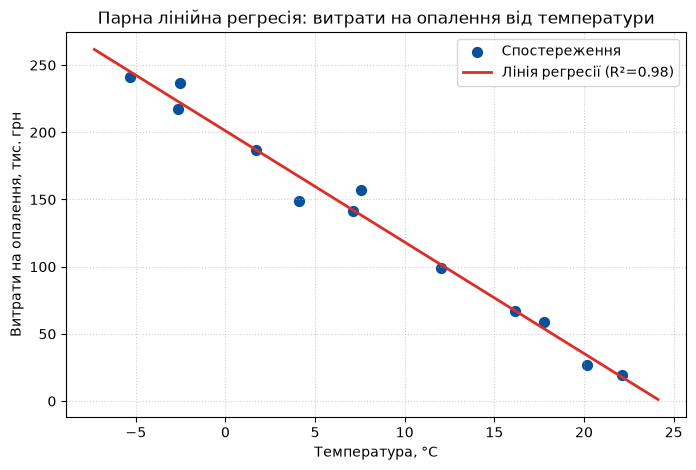

In [3]:
x_grid = np.linspace(temp_obs.min() - 2, temp_obs.max() + 2, 100)
y_pred = reg_res.intercept + reg_res.slope * x_grid

plt.figure(figsize=(8, 5))
plt.scatter(temp_obs, heating_cost, color="#08519c", label="Спостереження", s=50)
plt.plot(x_grid, y_pred, color="#de2d26", lw=2, label=f"Лінія регресії (R²={r_sq:.2f})")
plt.xlabel("Температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title("Парна лінійна регресія: витрати на опалення від температури")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()


Середнє арифметичне залишків: 1.3323e-14 (практично 0)


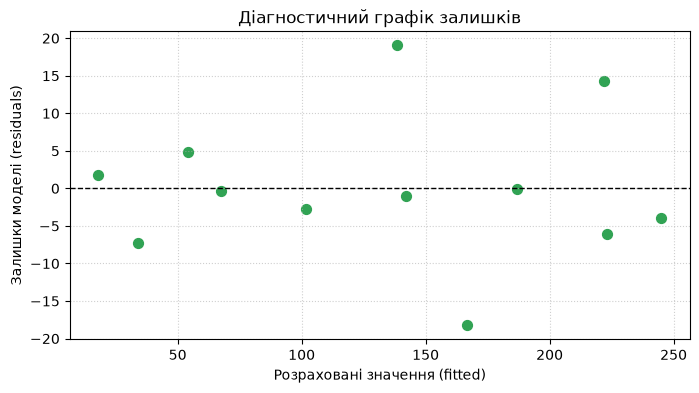

In [4]:
fitted_values = reg_res.intercept + reg_res.slope * temp_obs
residuals = heating_cost - fitted_values

plt.figure(figsize=(8, 4))
plt.scatter(fitted_values, residuals, color="#31a354", s=50)
plt.axhline(0, color="black", linestyle="--", lw=1)
plt.xlabel("Розраховані значення (fitted)")
plt.ylabel("Залишки моделі (residuals)")
plt.title("Діагностичний графік залишків")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

print(f"Середнє арифметичне залишків: {residuals.mean():.4e} (практично 0)")


In [5]:
t_extrapolate = -15.0
cost_predicted = reg_res.intercept + reg_res.slope * t_extrapolate

print(f"Діапазон температури у вибірці: [{temp_obs.min():.1f}; {temp_obs.max():.1f}] °C")
print(f"Прогноз витрат для {t_extrapolate}°C: {cost_predicted:.2f} тис. грн")
print("Застереження: Прогноз є екстраполяцією за межі емпіричних спостережень, тому його надійність суттєво нижча.")


Діапазон температури у вибірці: [-5.3; 22.1] °C
Прогноз витрат для -15.0°C: 325.35 тис. грн
Застереження: Прогноз є екстраполяцією за межі емпіричних спостережень, тому його надійність суттєво нижча.


In [6]:
from scipy.stats import pearsonr

p_slope = reg_res.pvalue
p_corr = pearsonr(temp_obs, heating_cost)[1]

print(f"p-value для нахилу регресії: {p_slope:.4e}")
print(f"p-value коефіцієнта кореляції Пірсона: {p_corr:.4e}")
print("Висновок: Обидва показники збігаються, оскільки перевіряють еквівалентну гіпотезу про наявність лінійного зв'язку.")


p-value для нахилу регресії: 2.0250e-10
p-value коефіцієнта кореляції Пірсона: 2.0250e-10
Висновок: Обидва показники збігаються, оскільки перевіряють еквівалентну гіпотезу про наявність лінійного зв'язку.


### Відповіді на контрольні запитання

1. **Чому метод найменших квадратів мінімізує саме суму квадратів залишків, а не модулів чи самих залишків?**  
   - Мінімізація простих залишків неможлива, оскільки додатні та від'ємні відхилення компенсують одне одного (сума залишків завжди тотожно дорівнює нулю для будь-якої прямої, що проходить через центроїд).
   - Квадратична функція втрат є всюди гладкою та неперервно диференційовною, що дозволяє отримати аналітичні замкнені формули для оцінок МНК через систему нормальних рівнянь. Модулі (L1-регресія) не мають похідної в нулі і вимагають чисельних методів лінійного програмування.

2. **Що виражає коефіцієнт нахилу $b_1$ і чим він відрізняється від кореляції $r$?**  
   Коефіцієнт $b_1$ має розмірність ($Y / X$) та показує абсолютну зміну відгуку при зміні фактора на 1 одиницю. Коефіцієнт кореляції $r$ є безрозмірним нормованим індикатором сили лінійного зв'язку у шкалі $[-1; 1]$. Зв'язок між ними описується формулою $b_1 = r \cdot \frac{s_y}{s_x}$.

3. **Чому високий $R^2$ не є гарантією коректності моделі та для чого потрібен аналіз залишків?**  
   Високий $R^2$ може бути отриманий навіть на явно нелінійних даних, якщо присутній сильний загальний тренд. Лише графік залишків дозволяє переконатися у виконанні передумов теореми Гаусса-Маркова: відсутності нелінійних патернів, постійності дисперсії (гомоскедастичності) та незалежності помилок.

4. **Як змінюється надійність прогнозу при виході за межі вибіркового діапазону?**  
   Прогнозування поза межами вибірки є екстраполяцією. Довірча смуга прогнозу має гіперболічну форму і різко розширюється при віддаленні від середнього значення $\bar{x}$, оскільки лінійна залежність за межами спостережуваних даних може втрачати чинність.
